In [1]:
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, \
    create_error_visualization
from ml_features.features import prepare_features
from ml_features.customer_features import create_customer_features
from ml_features.sequence_features  import create_sequence_features
from ml_features.brand_features import create_brand_features
from ml_features.model_features import create_model_features
from ml_features.market_features import create_market_features
from ml_features.equipment_features import create_equipment_features
from ml_features.solution_complexity_features import create_solution_complexity_features
from ml_features.timeline_features import create_timeline_features, create_advanced_timeline_features, create_timeline_interaction_features
from ml_features.role_features import create_commercial_role_features
from ml_features.process_features import create_process_features
from ml_features.correction_features import create_correction_features
from ml_features.catboost_interaction_features import create_catboost_interaction_features
from ml_features.efficiency_interation_features import create_efficiency_interaction_features
from ml_features.engagement_interation_features import create_engagement_interaction_features
from ml_features.advanced_features import create_advanced_interaction_features, create_conversion_pattern_features, create_precision_optimization_features, create_price_dominant_features
from ml_features.price_binning_features import create_price_binning_features
from ml_features.simulation_discovery import create_simulation_discovery_features
from ml_training.train_xgb import train_xgb
from ml_evaluation.dashboard import model_evaluation_report
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')


df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# AGGREGATE CENSUS DATA BY REGION
print("\n=== AGGREGATING CENSUS DATA BY REGION ===\n")

import pandas as pd

# Load census data
census = pd.read_csv('census_commune_features.csv')
print(f"Loaded {len(census):,} communes")

# Add region mapping from department code
region_codes = {
    '11': 'Île-de-France',
    '24': 'Centre-Val de Loire',
    '27': 'Bourgogne-Franche-Comté',
    '28': 'Normandie',
    '32': 'Hauts-de-France',
    '44': 'Grand Est',
    '52': 'Pays de la Loire',
    '53': 'Bretagne',
    '75': 'Nouvelle-Aquitaine',
    '76': 'Occitanie',
    '84': 'Auvergne-Rhône-Alpes',
    '93': 'Provence-Alpes-Côte d\'Azur',
    '94': 'Corse'
}

# Extract department code (first 2 digits of INSEE)
census['dept_code'] = census['insee_code'].astype(str).str[:2]
census['region_name'] = census['dept_code'].map(region_codes).fillna('Unknown')

# Group by region
census_by_region = census.groupby('region_name').agg({
    'pct_houses': 'mean',
    'pct_pre_1970': 'mean',
    'pct_electric_heating': 'mean',
    'pct_gas_heating': 'mean',
    'pct_collective_heating': 'mean',
    'pct_other_heating': 'mean',
    'pct_ac': 'mean',
    'pct_large_home_80m2': 'mean',
    'pct_large_home_4rooms': 'mean',
    'pct_2plus_cars': 'mean',
    'pct_social_housing': 'mean',
    'housing_count': 'sum'
}).reset_index()

# print("\n✅ Census data aggregated by region:")
# print(census_by_region.to_string())


=== AGGREGATING CENSUS DATA BY REGION ===

Loaded 34,914 communes


In [3]:
# Get unique customers
all_customers = df_quotes['numero_compte'].unique()

# Split customers (80/20)
train_customers, test_customers = train_test_split(
    all_customers, test_size=0.2, random_state=42
)

print(f"Train customers: {len(train_customers):,}")
print(f"Test customers: {len(test_customers):,}")

Train customers: 20,572
Test customers: 5,144


In [4]:
with redirect_stdout(open('/dev/null', 'w')):
    feature_funcs = [create_customer_features, create_sequence_features, create_brand_features,
                     create_model_features, create_market_features,
                     create_equipment_features, create_solution_complexity_features,
                     create_timeline_features, create_advanced_timeline_features,
                     create_commercial_role_features, create_process_features,
                     create_correction_features
                     ]
    
    new_df = feature_funcs[0](df_quotes)
    for func in feature_funcs[1:]:
        new_df_ = func(df_quotes)
        new_df = pd.merge(new_df, new_df_, on='numero_compte', how='left', suffixes=('_dup', ''))
        new_df = new_df.drop(columns=[x for x in new_df.columns if '_dup' in x], errors='ignore')
    
    print(f"\n✅ Customer-level features created: {len(new_df):,} customers")
    
    print("\n" + "=" * 80)
    print("🔧 ADDING INTERACTION FEATURES")
    print("=" * 80)
    
    new_df = create_timeline_interaction_features(new_df)
    new_df, _ = create_catboost_interaction_features(new_df)
    new_df, _ = create_efficiency_interaction_features(new_df)
    new_df, _ = create_engagement_interaction_features(new_df)
    new_df = create_advanced_interaction_features(new_df)
    new_df = create_conversion_pattern_features(new_df)
    new_df = create_precision_optimization_features(new_df)
    new_df = create_price_dominant_features(new_df)
    new_df = create_price_binning_features(new_df)
    new_df = create_simulation_discovery_features(new_df)
    
    new_df = new_df.merge(
        census_by_region,
        left_on='main_region',
        right_on='region_name',
        how='left'
    )


# Prepare train data
X_train = new_df[new_df['numero_compte'].isin(train_customers)] \
    .drop(columns=['numero_compte', 'converted'], errors='ignore').copy()
y_train = new_df[new_df['numero_compte'].isin(train_customers)]['converted']

# Prepare test data
X_test = new_df[new_df['numero_compte'].isin(test_customers)] \
    .drop(columns=['numero_compte', 'converted'], errors='ignore').copy()
y_test = new_df[new_df['numero_compte'].isin(test_customers)]['converted']

# Apply prepare_features
X_train_clean, y_train_clean, encoders, feature_order = prepare_features(X_train, y_train, 'train')
X_test_clean, y_test_clean = prepare_features(X_test, y_test, 'test', encoders=encoders, feature_order=feature_order)

# Train
X_test_clean_all = X_test_clean
y_test_clean_all = y_test_clean
result = train_xgb(X_train_clean, y_train_clean, 'model_all', X_test=X_test_clean, y_test=y_test_clean)


🔧 ENCODING & PREPARING FOR MODELING...
  Preparing train...

🔧 ENCODING & PREPARING FOR MODELING...
  Preparing test...
Using provided test set for evaluation.
✓ Model saved: model_all.pkl
✓ AUC: 0.769
✓ F1 Score: 0.628
✓ Training samples: 20572
✓ Test samples: 5144



📊 MODEL EVALUATION - REGION CENSUS CUSTOMERS
COMPLETE MODEL VALIDATION PACKAGE

📊 STEP 1: DISCRIMINATION POWER
----------------------------------------


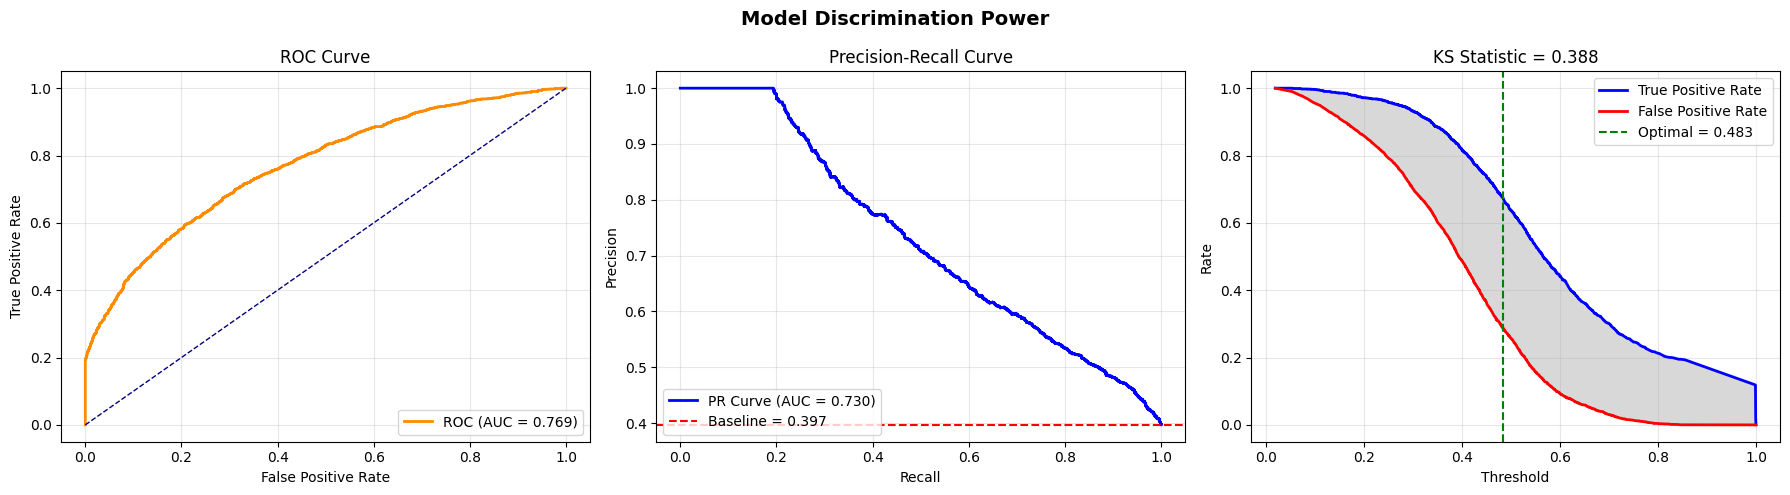

• ROC-AUC: 0.7688
• PR-AUC: 0.7299
• KS Statistic: 0.388 (MODERATE discrimination)
• Optimal Threshold: 0.483

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.948
Decile 10 mean prob: 0.130


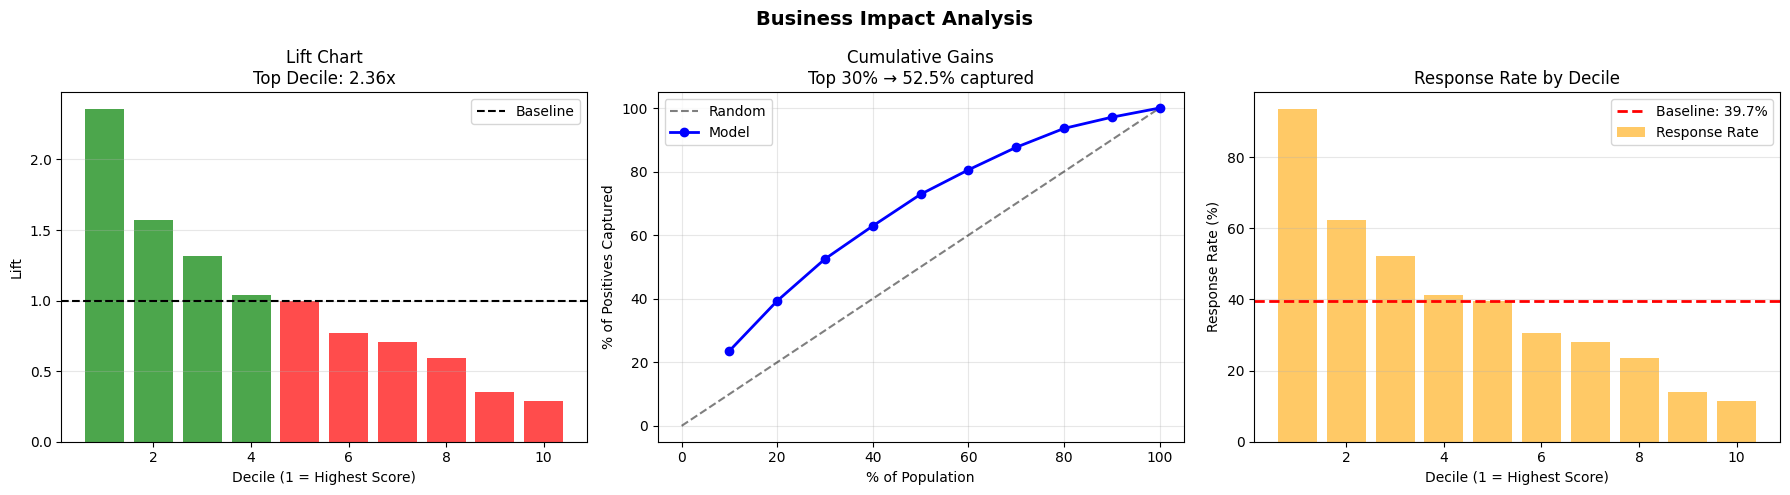

• Top Decile Lift: 0.29x
• Top 30% captures: 52.5% of positives
• Baseline response rate: 39.7%
• Top decile response: 93.6%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


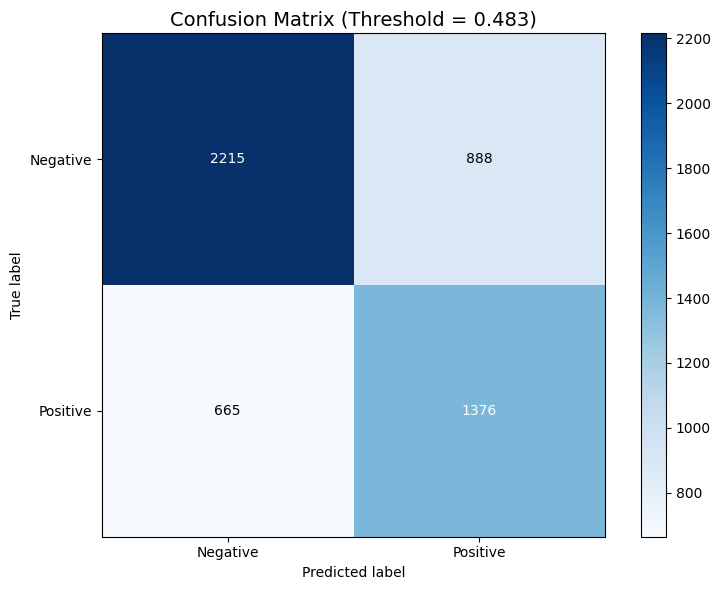

At threshold 0.483:
• Accuracy: 0.698
• Precision: 0.608
• Recall: 0.674
• F1-Score: 0.639
• True Positives: 1376
• False Positives: 888
• True Negatives: 2215
• False Negatives: 665

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.388 (MODERATE discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.29x better than random
   Coverage: Top 30% → 52.5% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.7688 (Excellent if >0.8)
   PR-AUC: 0.7299 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.483
   Precision at threshold: 0.608
   Recall at threshold: 0.674

🔍 FEATURE IMPORTANCE - REGION CENSUS MODEL

Top 20 Features:
                               feature  importance
56   consistency_distance_from_perfect    0.124595
130                   is_quick_decider    0.046067
60              converter_pattern_rank    0.029061
311                        value_score    0.028410
67           decision_efficiency_score    0.024858
45               browser_pattern_score    

In [5]:
print("\n" + "=" * 80)
print("📊 MODEL EVALUATION - REGION CENSUS CUSTOMERS")
print("=" * 80)

df_eval = result['X_test'].copy()
df_eval['converted'] = result['y_test']

model_evaluation_report(df_eval, result['model'], result['features'], 'converted')

print("\n" + "=" * 80)
print("🔍 FEATURE IMPORTANCE - REGION CENSUS MODEL")
print("=" * 80)

feature_importance = pd.DataFrame({
    'feature': result['features'],
    'importance': result['model'].feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 Features:")
print(feature_importance.head(50))

print("\n" + "=" * 80)
print("🧪 SIMULATION-DISCOVERY FEATURES IN SUBPOPULATION MODEL")
print("=" * 80)

simulation_features = [
    'heat_pump_to_stove_opportunity',
    'boiler_to_ac_opportunity',
    'cold_region_heat_pump',
    'cold_heat_pump_to_stove',
    'follow_up_opportunity'
]

print("\nFeature Importances for Simulation-Discovery Features:")
for feat in simulation_features:
    if feat in feature_importance['feature'].values:
        imp = feature_importance[feature_importance['feature'] == feat]['importance'].values[0]
        rank = feature_importance[feature_importance['feature'] == feat].index[0] + 1
        print(f"  #{rank}: {feat}: {imp:.4f}")
    else:
        print(f"  ❌ {feat}: NOT FOUND")

print("\n" + "=" * 80)
print("✅ MODEL TRAINING COMPLETE")
print("=" * 80)

if feat in feature_importance['feature'].values:
    imp = feature_importance[feature_importance['feature'] == feat]['importance'].values[0]
    rank = feature_importance[feature_importance['feature'] == feat].index[0] + 1
    print(f"  #{rank}: {feat}: {imp:.4f}")
else:
    print(f"  ❌ {feat}: NOT FOUND")

In [6]:
# Count quotes per customer
quote_counts = df_quotes.groupby('numero_compte').size().reset_index(name='quote_count')

# Get customers with 2+ quotes
multi_quote_ids = quote_counts[quote_counts['quote_count'] >= 2]['numero_compte'].tolist()

# Filter data
df_quotes_multi = df_quotes[df_quotes['numero_compte'].isin(multi_quote_ids)].copy()

print(f"Original customers: {df_quotes['numero_compte'].nunique():,}")
print(f"Multiple quote customers (≥2): {len(multi_quote_ids):,}")
print(f"Quotes: {len(df_quotes_multi):,}")

# Save to file
df_quotes_multi.to_csv('cleaned_quote_data_multi.csv', index=False)
print(f"\n✅ Saved to cleaned_quote_data_multi.csv")

Original customers: 25,716
Multiple quote customers (≥2): 7,858
Quotes: 19,150

✅ Saved to cleaned_quote_data_multi.csv


In [7]:
df_quotes_engaged = pd.read_csv('cleaned_quote_data_multi.csv')

with redirect_stdout(open('/dev/null', 'w')):
    feature_funcs = [create_customer_features, create_sequence_features, create_brand_features,
                     create_model_features, create_market_features,
                     create_equipment_features, create_solution_complexity_features,
                     create_timeline_features, create_advanced_timeline_features,
                     create_commercial_role_features, create_process_features,
                     create_correction_features
                     ]
    
    new_df = feature_funcs[0](df_quotes_engaged)
    for func in feature_funcs[1:]:
        new_df_ = func(df_quotes_engaged)
        new_df = pd.merge(new_df, new_df_, on='numero_compte', how='left', suffixes=('_dup', ''))
        new_df = new_df.drop(columns=[x for x in new_df.columns if '_dup' in x], errors='ignore')
    
    print(f"\n✅ Customer-level features created: {len(new_df):,} customers")
    
    print("\n" + "=" * 80)
    print("🔧 ADDING INTERACTION FEATURES")
    print("=" * 80)
    
    new_df = create_timeline_interaction_features(new_df)
    new_df, _ = create_catboost_interaction_features(new_df)
    new_df, _ = create_efficiency_interaction_features(new_df)
    new_df, _ = create_engagement_interaction_features(new_df)
    new_df = create_advanced_interaction_features(new_df)
    new_df = create_conversion_pattern_features(new_df)
    new_df = create_precision_optimization_features(new_df)
    new_df = create_price_dominant_features(new_df)
    new_df = create_price_binning_features(new_df)
    new_df = create_simulation_discovery_features(new_df)
    
    new_df = new_df.merge(
        census_by_region,
        left_on='main_region',
        right_on='region_name',
        how='left'
    )

# Prepare train data
X_train = new_df[new_df['numero_compte'].isin(train_customers)] \
    .drop(columns=['numero_compte', 'converted'], errors='ignore').copy()
y_train = new_df[new_df['numero_compte'].isin(train_customers)]['converted']

# Prepare test data
X_test = new_df[new_df['numero_compte'].isin(test_customers)] \
    .drop(columns=['numero_compte', 'converted'], errors='ignore').copy()
y_test = new_df[new_df['numero_compte'].isin(test_customers)]['converted']

# Apply prepare_features
X_train_clean, y_train_clean = prepare_features(X_train, y_train, 'train', encoders=encoders, feature_order=feature_order)
X_test_clean, y_test_clean = prepare_features(X_test, y_test, 'test', encoders=encoders, feature_order=feature_order)

# Train
result_engaged = train_xgb(X_train_clean, y_train_clean, 'model_engaged', X_test=X_test_clean, y_test=y_test_clean)


🔧 ENCODING & PREPARING FOR MODELING...
  Preparing train...

🔧 ENCODING & PREPARING FOR MODELING...
  Preparing test...
Using provided test set for evaluation.
✓ Model saved: model_engaged.pkl
✓ AUC: 0.878
✓ F1 Score: 0.771
✓ Training samples: 6200
✓ Test samples: 1658



📊 MODEL EVALUATION - REGION CENSUS CUSTOMERS
COMPLETE MODEL VALIDATION PACKAGE

📊 STEP 1: DISCRIMINATION POWER
----------------------------------------


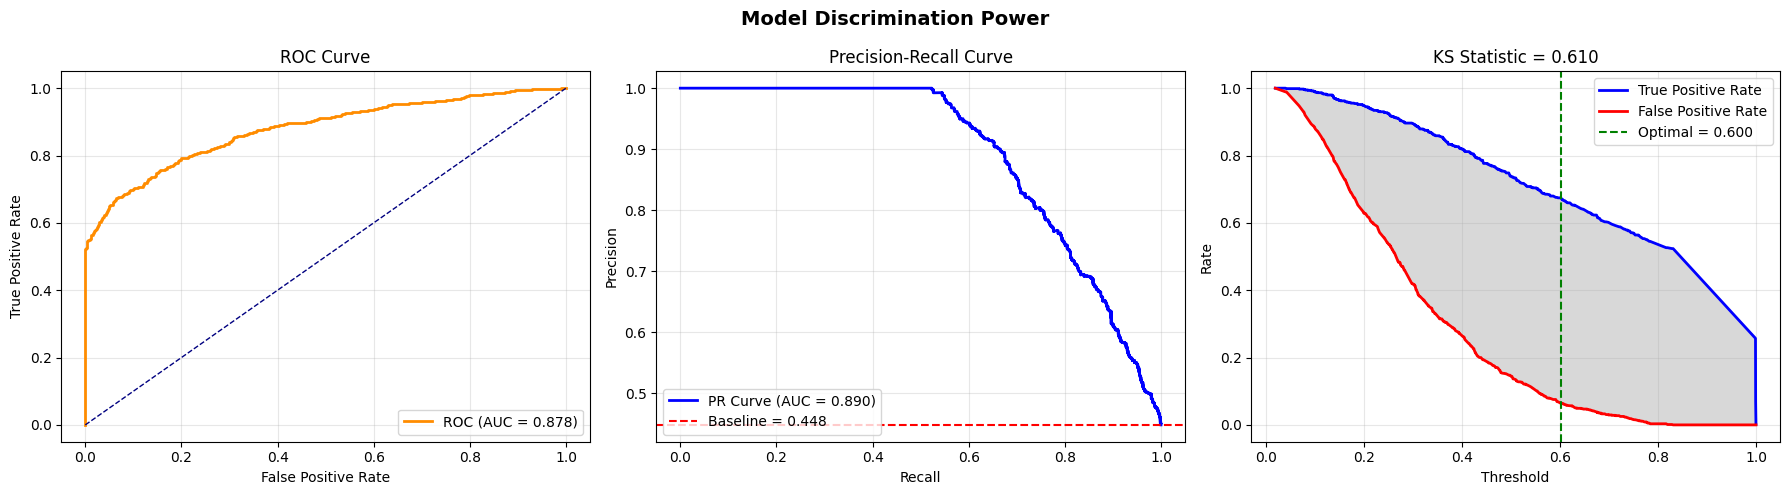

• ROC-AUC: 0.8779
• PR-AUC: 0.8903
• KS Statistic: 0.610 (OUTSTANDING discrimination)
• Optimal Threshold: 0.600

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.999
Decile 10 mean prob: 0.081


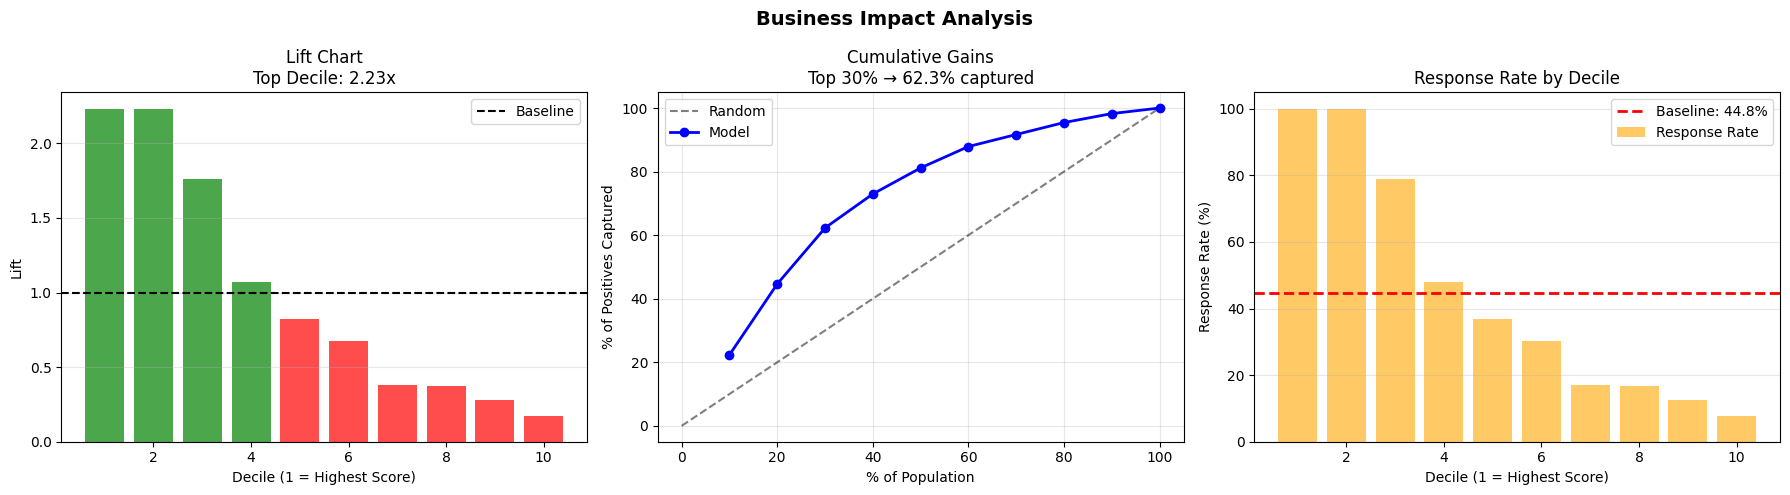

• Top Decile Lift: 0.17x
• Top 30% captures: 62.3% of positives
• Baseline response rate: 44.8%
• Top decile response: 100.0%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


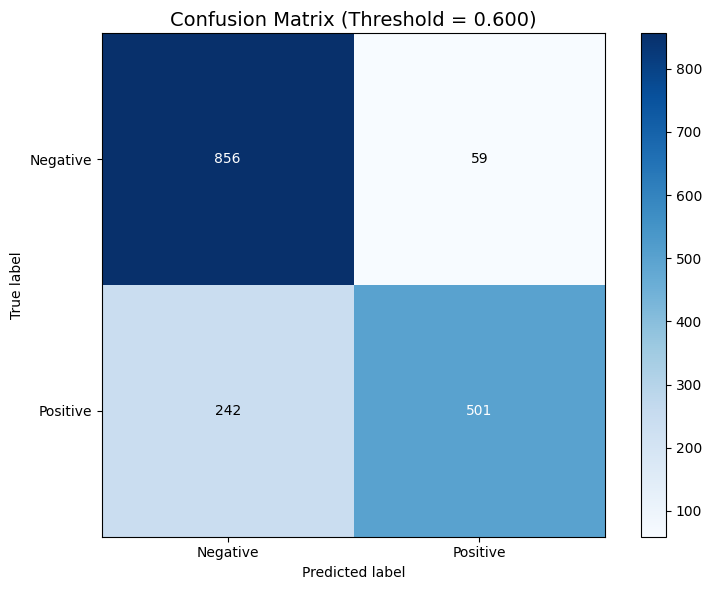

At threshold 0.600:
• Accuracy: 0.818
• Precision: 0.895
• Recall: 0.674
• F1-Score: 0.769
• True Positives: 501
• False Positives: 59
• True Negatives: 856
• False Negatives: 242

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.610 (OUTSTANDING discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.17x better than random
   Coverage: Top 30% → 62.3% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.8779 (Excellent if >0.8)
   PR-AUC: 0.8903 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.600
   Precision at threshold: 0.895
   Recall at threshold: 0.674

🔍 FEATURE IMPORTANCE - REGION CENSUS MODEL

Top 20 Features:
                               feature  importance
56   consistency_distance_from_perfect    0.124595
130                   is_quick_decider    0.046067
60              converter_pattern_rank    0.029061
311                        value_score    0.028410
67           decision_efficiency_score    0.024858
45               browser_pattern_score    

In [8]:
print("\n" + "=" * 80)
print("📊 MODEL EVALUATION - REGION CENSUS CUSTOMERS")
print("=" * 80)

df_eval = result_engaged['X_test'].copy()
df_eval['converted'] = result_engaged['y_test']

model_evaluation_report(df_eval, result['model'], result['features'], 'converted')

print("\n" + "=" * 80)
print("🔍 FEATURE IMPORTANCE - REGION CENSUS MODEL")
print("=" * 80)

feature_importance = pd.DataFrame({
    'feature': result['features'],
    'importance': result['model'].feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 Features:")
print(feature_importance.head(50))

print("\n" + "=" * 80)
print("🧪 SIMULATION-DISCOVERY FEATURES IN SUBPOPULATION MODEL")
print("=" * 80)

simulation_features = [
    'heat_pump_to_stove_opportunity',
    'boiler_to_ac_opportunity',
    'cold_region_heat_pump',
    'cold_heat_pump_to_stove',
    'follow_up_opportunity'
]

print("\nFeature Importances for Simulation-Discovery Features:")
for feat in simulation_features:
    if feat in feature_importance['feature'].values:
        imp = feature_importance[feature_importance['feature'] == feat]['importance'].values[0]
        rank = feature_importance[feature_importance['feature'] == feat].index[0] + 1
        print(f"  #{rank}: {feat}: {imp:.4f}")
    else:
        print(f"  ❌ {feat}: NOT FOUND")

print("\n" + "=" * 80)
print("✅ MODEL TRAINING COMPLETE")
print("=" * 80)

if feat in feature_importance['feature'].values:
    imp = feature_importance[feature_importance['feature'] == feat]['importance'].values[0]
    rank = feature_importance[feature_importance['feature'] == feat].index[0] + 1
    print(f"  #{rank}: {feat}: {imp:.4f}")
else:
    print(f"  ❌ {feat}: NOT FOUND")


=== TRAINING ENGAGEMENT PREDICTOR ===


🔧 ENCODING & PREPARING FOR MODELING...
  Preparing train...

🔧 ENCODING & PREPARING FOR MODELING...
  Preparing test...
Using provided test set for evaluation.
✓ Model saved: engagement_predictor.pkl
✓ AUC: 0.660
✓ F1 Score: 0.506
✓ Training samples: 20572
✓ Test samples: 5144
COMPLETE MODEL VALIDATION PACKAGE

📊 STEP 1: DISCRIMINATION POWER
----------------------------------------


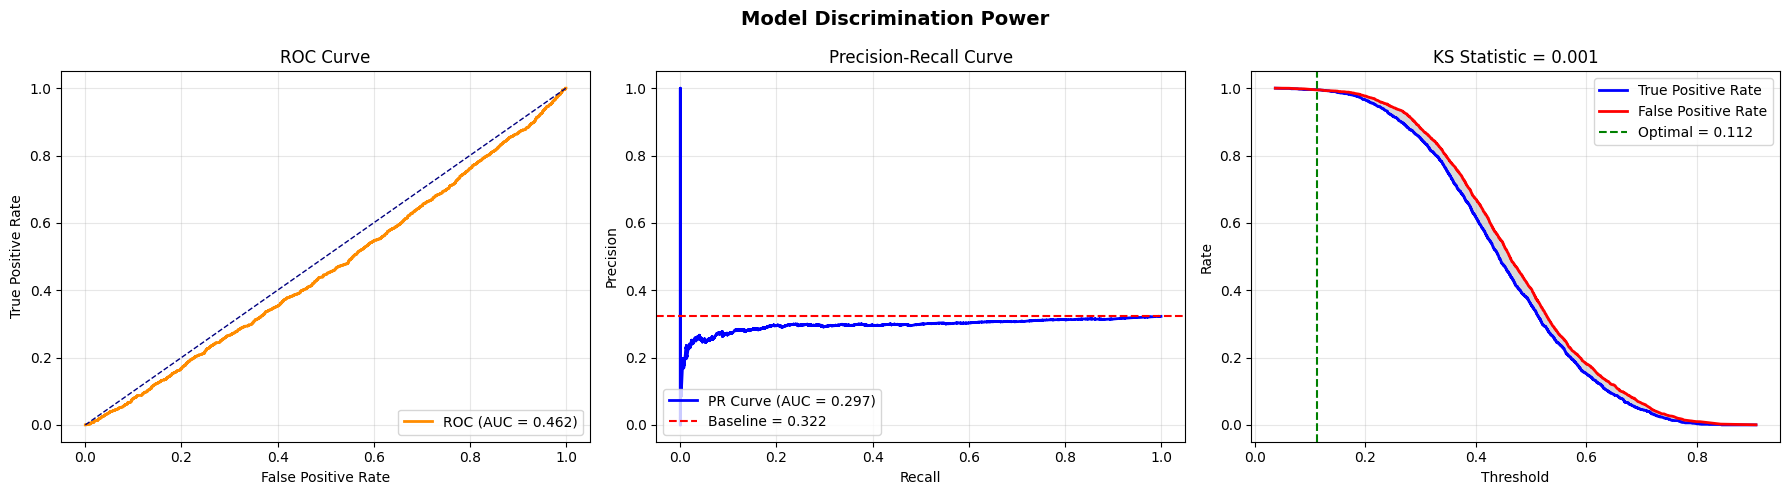

• ROC-AUC: 0.4619
• PR-AUC: 0.2968
• KS Statistic: 0.001 (WEAK discrimination)
• Optimal Threshold: 0.112

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.720
Decile 10 mean prob: 0.221


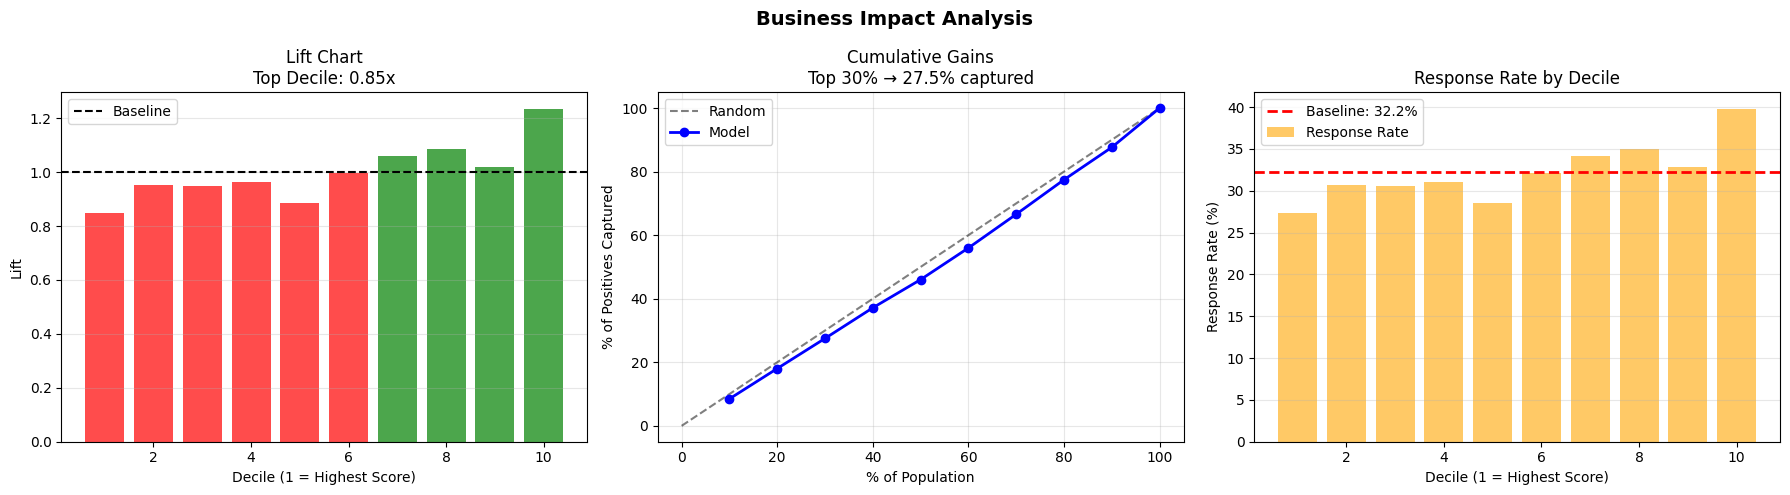

• Top Decile Lift: 1.23x
• Top 30% captures: 27.5% of positives
• Baseline response rate: 32.2%
• Top decile response: 27.4%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


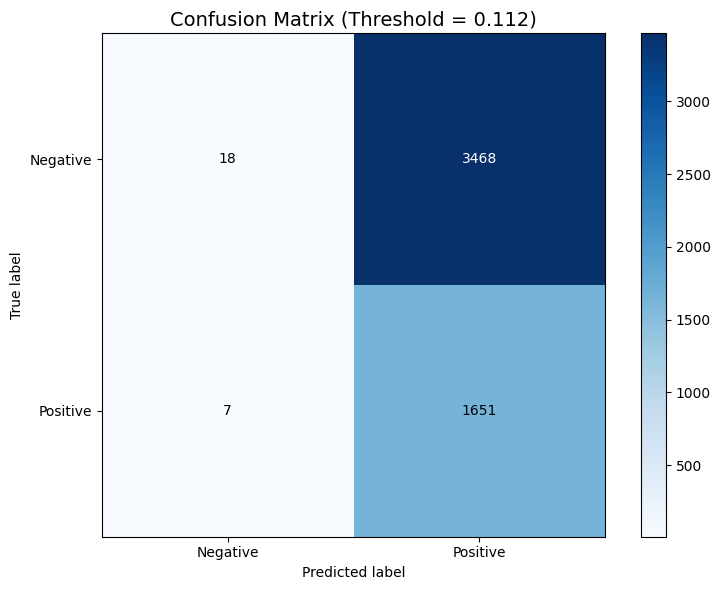

At threshold 0.112:
• Accuracy: 0.324
• Precision: 0.323
• Recall: 0.996
• F1-Score: 0.487
• True Positives: 1651
• False Positives: 3468
• True Negatives: 18
• False Negatives: 7

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.001 (WEAK discrimination)

✅ BUSINESS VALUE:
   Efficiency: 1.23x better than random
   Coverage: Top 30% → 27.5% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.4619 (Excellent if >0.8)
   PR-AUC: 0.2968 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.112
   Precision at threshold: 0.323
   Recall at threshold: 0.996

Top 20 Features:
                               feature  importance
56   consistency_distance_from_perfect    0.124595
130                   is_quick_decider    0.046067
60              converter_pattern_rank    0.029061
311                        value_score    0.028410
67           decision_efficiency_score    0.024858
45               browser_pattern_score    0.019376
102                has_cooling_systems    

In [9]:
# ENGAGEMENT PREDICTOR - ADAPTED FOR ENGAGEMENT
print("\n=== TRAINING ENGAGEMENT PREDICTOR ===\n")


# Step 1: Create first quotes dataset with engagement target
df_first_quotes = df_quotes.sort_values('dt_creation_devis').groupby('numero_compte').first().reset_index()
quote_counts = df_quotes.groupby('numero_compte').size().reset_index(name='eventual_quotes')
df_first_quotes = df_first_quotes.merge(quote_counts, on='numero_compte')
df_first_quotes['engagement_target'] = (df_first_quotes['eventual_quotes'] >= 2).astype(int)

engagement_targets = df_first_quotes[['numero_compte', 'engagement_target']].copy()
with redirect_stdout(open('/dev/null', 'w')):
    feature_funcs = [create_customer_features, create_sequence_features, create_brand_features,
                     create_model_features, create_market_features,
                     create_equipment_features, create_solution_complexity_features,
                     create_timeline_features, create_advanced_timeline_features,
                     create_commercial_role_features, create_process_features,
                     create_correction_features
                     ]
    
    new_df = feature_funcs[0](df_first_quotes)
    for func in feature_funcs[1:]:
        new_df_ = func(df_first_quotes)
        new_df = pd.merge(new_df, new_df_, on='numero_compte', how='left', suffixes=('_dup', ''))
        new_df = new_df.drop(columns=[x for x in new_df.columns if '_dup' in x], errors='ignore')
    
    print(f"\n✅ Customer-level features created: {len(new_df):,} customers")
    
    print("\n" + "=" * 80)
    print("🔧 ADDING INTERACTION FEATURES")
    print("=" * 80)
    
    new_df = create_timeline_interaction_features(new_df)
    new_df, _ = create_catboost_interaction_features(new_df)
    new_df, _ = create_efficiency_interaction_features(new_df)
    new_df, _ = create_engagement_interaction_features(new_df)
    new_df = create_advanced_interaction_features(new_df)
    new_df = create_conversion_pattern_features(new_df)
    new_df = create_precision_optimization_features(new_df)
    new_df = create_price_dominant_features(new_df)
    new_df = create_price_binning_features(new_df)
    new_df = create_simulation_discovery_features(new_df)
    
    new_df = new_df.merge(
        census_by_region,
        left_on='main_region',
        right_on='region_name',
        how='left'
    )

    new_df = new_df.merge(engagement_targets, on='numero_compte', how='left')

X_train = new_df[new_df['numero_compte'].isin(train_customers)] \
    .drop(columns=['numero_compte', 'converted', 'engagement_target'], errors='ignore').copy()
y_train = new_df[new_df['numero_compte'].isin(train_customers)]['engagement_target']

# Step 5: Prepare test data
X_test = new_df[new_df['numero_compte'].isin(test_customers)] \
    .drop(columns=['numero_compte', 'converted', 'engagement_target'], errors='ignore').copy()
y_test = new_df[new_df['numero_compte'].isin(test_customers)]['engagement_target']

# Step 6: Apply prepare_features
X_train_clean, y_train_clean = prepare_features(X_train, y_train, 'train', encoders=encoders, feature_order=feature_order)
X_test_clean, y_test_clean = prepare_features(X_test, y_test, 'test', encoders=encoders, feature_order=feature_order)

# Step 7: Train engagement predictor
engagement_result = train_xgb(X_train_clean, y_train_clean, 'engagement_predictor', X_test=X_test_clean, y_test=y_test_clean)


df_eval = engagement_result['X_test'].copy()
df_eval['engagement_target'] = engagement_result['y_test']

model_evaluation_report(df_eval, result['model'], result['features'], 'engagement_target')

feature_importance = pd.DataFrame({
    'feature': result['features'],
    'importance': result['model'].feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 Features:")
print(feature_importance.head(50))


print("\n" + "=" * 80)
print("✅ MODEL TRAINING COMPLETE")
print("=" * 80)

if feat in feature_importance['feature'].values:
    imp = feature_importance[feature_importance['feature'] == feat]['importance'].values[0]
    rank = feature_importance[feature_importance['feature'] == feat].index[0] + 1
    print(f"  #{rank}: {feat}: {imp:.4f}")
else:
    print(f"  ❌ {feat}: NOT FOUND")

# DIAGNOSE FEATURE DIFFERENCES
print("\n=== FEATURE DIFFERENCE ANALYSIS ===\n")

# Get feature sets
engage_features = set(engagement_result['features'])
high_features = set(result_engaged['features'])
base_features = set(result['features'])

print(f"Engagement model features: {len(engage_features)}")
print(f"High engagement model features: {len(high_features)}")
print(f"Baseline model features: {len(base_features)}")

# Features only in baseline (not in others)
only_in_base = base_features - engage_features - high_features
print(f"\nFeatures ONLY in baseline ({len(only_in_base)}):")
for f in sorted(only_in_base)[:20]:
    print(f"  - {f}")
if len(only_in_base) > 20:
    print(f"  ... and {len(only_in_base) - 20} more")

# Features only in engagement (not in others)
only_in_engage = engage_features - base_features - high_features
print(f"\nFeatures ONLY in engagement ({len(only_in_engage)}):")
for f in sorted(only_in_engage)[:20]:
    print(f"  - {f}")
if len(only_in_engage) > 20:
    print(f"  ... and {len(only_in_engage) - 20} more")

# Features only in high engagement
only_in_high = high_features - base_features - engage_features
print(f"\nFeatures ONLY in high engagement ({len(only_in_high)}):")
for f in sorted(only_in_high)[:20]:
    print(f"  - {f}")
if len(only_in_high) > 20:
    print(f"  ... and {len(only_in_high) - 20} more")

# Features in all three
common_all = engage_features & high_features & base_features
print(f"\nFeatures in ALL THREE models: {len(common_all)}")

# Check specific suspicious features
suspicious = ['quote_count', 'engagement_target', 'converted', 'numero_compte']
print(f"\nChecking suspicious features:")
for f in suspicious:
    print(f"  {f}:")
    print(f"    - In baseline: {f in base_features}")
    print(f"    - In engagement: {f in engage_features}")
    print(f"    - In high engagement: {f in high_features}")

In [14]:
# TWO-STAGE SYSTEM - CORRECT IMPLEMENTATION
print("\n" + "="*80)
print("TWO-STAGE SYSTEM EVALUATION (CORRECT)")
print("="*80)

# Get test set from baseline model
X_test_base = result['X_test']
y_test_base = result['y_test']

# Get engagement predictions for test customers
p_engage = engagement_result['model'].predict_proba(X_test_base)[:, 1]

# Get baseline predictions for ALL test customers
p_baseline = result['model'].predict_proba(X_test_base)[:, 1]

# Get predictions from high engagement model ONLY for customers we think will engage
# We need to align features
high_features = result_engaged['features']
X_test_aligned = X_test_base[high_features].copy()
p_high = result_engaged['model'].predict_proba(X_test_aligned)[:, 1]

# Combine: use high engagement model ONLY for customers with high engagement probability
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
best_auc = 0
best_threshold = 0.5

print("\nEvaluating thresholds:")
for threshold in thresholds:
    p_final = p_baseline.copy()
    # For customers with high engagement probability, use the high engagement model
    high_engage_mask = p_engage >= threshold
    p_final[high_engage_mask] = p_high[high_engage_mask]
    
    auc = roc_auc_score(y_test_base, p_final)
    print(f"  Threshold {threshold}: AUC = {auc:.4f}")
    if auc > best_auc:
        best_auc = auc
        best_threshold = threshold

print(f"\n✅ Best threshold: {best_threshold}")
print(f"✅ Two-Stage AUC: {best_auc:.4f}")
print(f"Baseline AUC: {result['metrics']['auc']:.4f}")
print(f"Improvement: {best_auc - result['metrics']['auc']:+.4f}")

# Segmentation analysis
high_engage_mask = p_engage >= best_threshold
print(f"\nCustomers classified as high engagement: {high_engage_mask.sum():,} ({high_engage_mask.mean():.1%})")
print(f"  Their conversion rate (baseline): {y_test_base[high_engage_mask].mean():.1%}")
print(f"  Their conversion rate (high engagement model): {p_high[high_engage_mask].mean():.1%}")

# Top decile analysis
test_df = pd.DataFrame({
    'y_true': y_test_base,
    'baseline': p_baseline,
    'two_stage': p_final
})

test_df['baseline_rank'] = test_df['baseline'].rank(pct=True)
test_df['two_stage_rank'] = test_df['two_stage'].rank(pct=True)

baseline_top = test_df[test_df['baseline_rank'] >= 0.9]
two_stage_top = test_df[test_df['two_stage_rank'] >= 0.9]

print(f"\nBaseline Top Decile: {baseline_top['y_true'].mean():.1%}")
print(f"Two-Stage Top Decile: {two_stage_top['y_true'].mean():.1%}")


TWO-STAGE SYSTEM EVALUATION (CORRECT)

Evaluating thresholds:
  Threshold 0.3: AUC = 0.7371
  Threshold 0.4: AUC = 0.7422
  Threshold 0.5: AUC = 0.7486
  Threshold 0.6: AUC = 0.7594
  Threshold 0.7: AUC = 0.7661

✅ Best threshold: 0.7
✅ Two-Stage AUC: 0.7661
Baseline AUC: 0.7688
Improvement: -0.0027

Customers classified as high engagement: 202 (3.9%)
  Their conversion rate (baseline): 39.1%
  Their conversion rate (high engagement model): 36.4%

Baseline Top Decile: 93.6%
Two-Stage Top Decile: 93.6%
